# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

Linear models are numeric and have a value between negative infinity and infinity, making restriction difficult. For example, in some instances the linear model sees values 0 and 1 as probabilities when in reality there could be some value past 0 and 1. In cases such as these latent variance modelas and activation functions are stronger because they assume a more categorical or continuous process.


2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Cross entropy is effective because it  measures how close predicted probabilities are to the true outcomes. Also, if there are confident yet wrong predictions there is penalization of it.

3. True or false, and explain: Logistic regression is a linear model.
TRUE because logistic regression is linear in the coefficients. The logistic regression model might involve log but there are integers involved representing the betas of the model making it linear.


4. True or false, and explain: Logistic regression cannot be used for classification.

False, logistic regression can be used for classification because it predicts probabilities which can be turned into classes or thresholds.


5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

The coefficient shows change in log odds. In other words, A 1-unit increase in x changes the log-odds by beta.


6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.


This is false because logistic regression has linear aspects to it. Because it is nonlinear but also has linear coefficients, there needs to be feature engineering for processses such as polynomial terms.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False; Linear regression is better for continous situations but logistic regression is better for categorical data so there is not any specific rule where one is always better.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?
Lower dropout is seen in the negative coefficients tuition and scholarships. Higher dropout is seen alongside positive like debtor and age. Tuition has a large coefficient so being up to data on this is important for reducing drop out risk.


3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?


On average, being up to date on tuition reduces dropout probability by about 51.6 percentage points. Students not up to date on tuition have consistently higher predicted dropout probabilities. This is most seen in the older ages.

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

76.2 %

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.
They both typically share the same patterns and peaks but there is more variance with the linear model histogram. Logistic outputs will typically be between 0 an 1 whereas the linear outputs will range away from that.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?
It seems older students and students who have debt or struggle financially are more at risk of dropping out. There need to be more financial interventions set up by the government or privates agencies through scholarships perhaps to allow for those who need funding to recieve it. Also there should be more intervention for lowering tuitions all around.


6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?
There seems to be all zeros in the middle row showing that there was no prediction there. Hard classification does not predict every class but probabilities did show every class.

In [1]:
#1
!git clone https://github.com/hershiaytoda/undergrad_ml_assignments.git
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 245, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 245 (delta 5), reused 1 (delta 1), pack-reused 237 (from 3)
Receiving objects: 100% (245/245), 18.53 MiB | 28.28 MiB/s, done.
Resolving deltas: 100% (107/107), done.


Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64
                  Variable  Coefficient
0                   Debtor     0.530625
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925


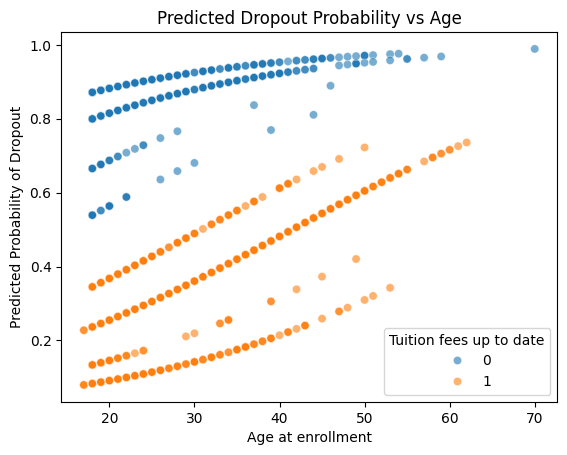

0.5161819741831828
[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


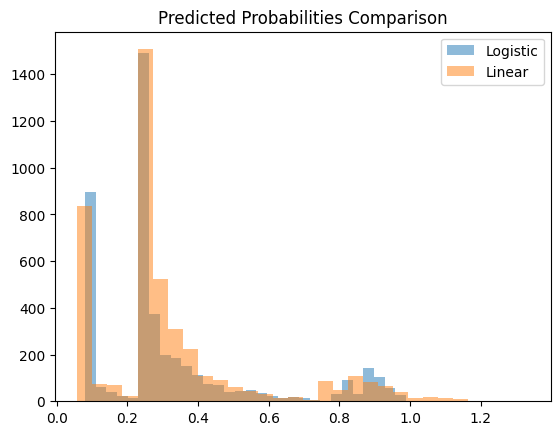

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [14]:
df = pd.read_csv('/content/undergrad_ml_assignments/data/data.csv', sep=";")

# Keep only relevant columns
cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]

df = df[cols].copy()

# handle missing values
print(df.isna().sum())

df = df.dropna()

df["dropout"] = (df["Target"] == "Dropout").astype(int)

from sklearn.linear_model import LogisticRegression

X = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]

y = df["dropout"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Coefficients
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})

print(coef_df)


#part 4

import matplotlib.pyplot as plt
import seaborn as sns

df["pred_prob"] = model.predict_proba(X)[:, 1]

plt.figure()
sns.scatterplot(
    data=df,
    x="Age at enrollment",
    y="pred_prob",
    hue="Tuition fees up to date",
    alpha=0.6
)

plt.title("Predicted Dropout Probability vs Age")
plt.ylabel("Predicted Probability of Dropout")
plt.show()

df_up = df.copy()
df_up["Tuition fees up to date"] = 1

df_not = df.copy()
df_not["Tuition fees up to date"] = 0

p_up = model.predict_proba(df_up[X.columns])[:,1]
p_not = model.predict_proba(df_not[X.columns])[:,1]

effect = (p_not - p_up).mean()
print(effect)

#5
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print(cm)
print("Accuracy:", acc)

#6
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

df["lin_prob"] = lin_model.predict(X)

plt.figure()
plt.hist(df["pred_prob"], bins=30, alpha=0.5, label="Logistic")
plt.hist(df["lin_prob"], bins=30, alpha=0.5, label="Linear")
plt.legend()
plt.title("Predicted Probabilities Comparison")
plt.show()

# 8

from sklearn.linear_model import LogisticRegression

X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]

y_multi = df["Target"]

multi_model = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi_model.fit(X_multi, y_multi)

# Predictions
y_pred_multi = multi_model.predict(X_multi)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_multi, y_pred_multi))

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

The coefficient for Bilirubin is negative suggesting higher bilirubin  and lower survival probability. Edema_Y and S is similar to the nature of Bilirubin as a result of the negative coefficient. The drug placebo is positive suggesting higher survival probability meaning the drug itself does not help improve survival.

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

Patientshave about a 1.9 % point lower survival probability on average.

Bilirubin seems to be better than the placebo at moderate levels of Bilirubin. Around the 5 point mark, there are points where the Bilirubin outperforms but also underperforms compared to the placebo. This pattern continues until the 15 point.

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

Model correctly predicts about 74% of cases.

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

The logistic regression notes a peak at 0.0 that the linear model misses. Other than that they are indentical in peaks and declines or skews of the histogram. The linear model has values at almost each point which makes it less descriptive whereas the logistic model is more informative. It is the better option at this point.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

Hard classification does not predict every class and includes zeros but predicted probabilities predict every class.

       Variable  Coefficient
0     Bilirubin    -0.351424
1       Edema_S    -0.450677
2       Edema_Y    -1.611049
3  Drug_Placebo     0.231225


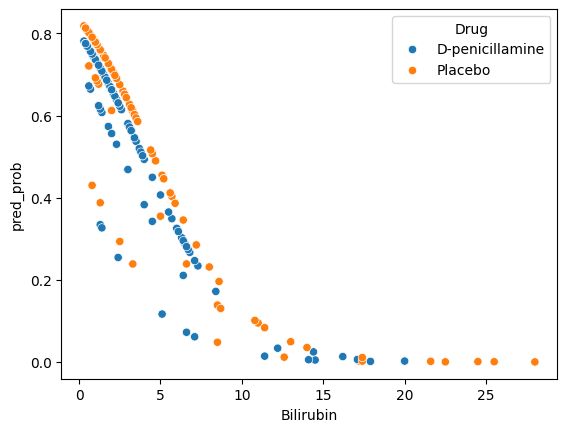

-0.018848501038509102
[[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


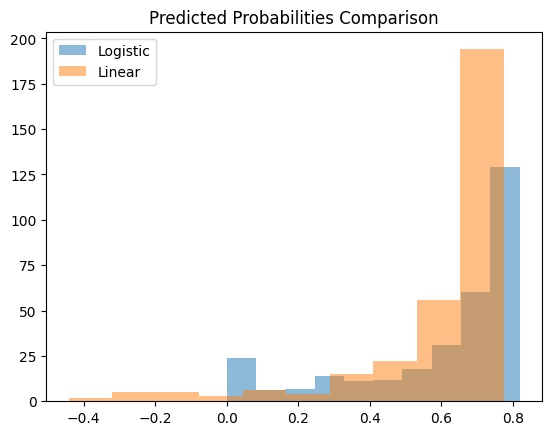

[[  0   0  16   0]
 [  0   0  62   5]
 [  0   0 105  15]
 [  0   0  69  40]]
[[1.48823241e-05 3.32455631e-02 1.30812413e-01 8.35927142e-01]
 [1.00367853e-01 2.55808709e-01 3.64287749e-01 2.79535689e-01]
 [4.11136381e-02 1.87088016e-01 3.71733197e-01 4.00065149e-01]
 [3.25913985e-02 1.82708129e-01 3.74022674e-01 4.10677799e-01]
 [1.13683082e-02 2.16273511e-01 4.49799583e-01 3.22558597e-01]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [34]:
df = pd.read_csv('/content/undergrad_ml_assignments/data/cirrhosis.csv', sep=",")
#print(df.isna().sum())
#print(df.head())
#print(df.columns.tolist())
df = df[["Bilirubin", "Edema", "Drug", "Stage", "Status"]]
df["Status"] = df["Status"].apply(lambda x: 1 if x in ["C", "CL"] else 0)
df = df.dropna()

#logistic regression

from sklearn.linear_model import LogisticRegression




from sklearn.linear_model import LogisticRegression

# One-hot encode categorical variables
df_enc = pd.get_dummies(df, columns=["Edema", "Drug"], drop_first=True)

X = df_enc.drop(columns=["Status", "Stage"])
y = df_enc["Status"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Coefficients
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})
print(coef_df)


probs = model.predict_proba(X)[:, 1]
df["pred_prob"] = probs


import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="Bilirubin", y="pred_prob", hue="Drug")
plt.show()

df["Drug_binary"] = df["Drug"].apply(lambda x: 1 if x == "D-penicillamine" else 0)

avg_drug = df[df["Drug_binary"] == 1]["pred_prob"].mean()
avg_placebo = df[df["Drug_binary"] == 0]["pred_prob"].mean()

effect = avg_drug - avg_placebo
print(effect)

#confusion Matrix
from sklearn.metrics import confusion_matrix, accuracy_score

preds = model.predict(X)

cm = confusion_matrix(y, preds)
acc = accuracy_score(y, preds)

print(cm)
print("Accuracy:", acc)


#comparison

from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

lin_probs = lin_model.predict(X)

df["lin_prob"] = lin_probs
plt.hist(probs, alpha=0.5, label="Logistic")
plt.hist(lin_probs, alpha=0.5, label="Linear")
plt.legend()
plt.title("Predicted Probabilities Comparison")
plt.show()


X_stage = df_enc.drop(columns=["Status", "Stage"])
y_stage = df_enc["Stage"]

stage_model = LogisticRegression(max_iter=1000, multi_class="multinomial")
stage_model.fit(X_stage, y_stage)

stage_preds = stage_model.predict(X_stage)

cm_stage = confusion_matrix(y_stage, stage_preds)
print(cm_stage)

stage_probs = stage_model.predict_proba(X_stage)
print(stage_probs[:5])



**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?